In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

**Import modules**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import warnings
warnings.filterwarnings("ignore")


**Set up - Install Wandb**

In [3]:
!pip uninstall -y wandb
!pip install --no-cache-dir wandb==0.22.3


Found existing installation: wandb 0.25.1
Uninstalling wandb-0.25.1:
  Successfully uninstalled wandb-0.25.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 224.3 MB/s eta 0:00:00a 0:00:01


In [4]:
import os
import gc
import time
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

import wandb
print("wandb version:", wandb.__version__)


wandb version: 0.22.3


**Wandb login**

In [5]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
WANDB_TOKEN = user_secrets.get_secret("WANDB_TOKEN")

wandb.login(key=WANDB_TOKEN)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

**Config**

In [6]:
CONFIG = {
    "max_len": 128,
    "vocab_size": 25000,
    "embed_dim": 128,
    "num_filters": 100,
    "filter_sizes": [3, 4, 5],
    "dropout": 0.3,
    "batch_size": 32,
    "epochs": 15,
    "lr": 1e-3,
    "seed": 42,
    "project": "DL-22f1000828-notebook-t22026",
    "entity": "22f1000828-t1-2026-indian-institute-of-technology-madras",
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

LABEL2IDX = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
IDX2LABEL = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}


In [7]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(CONFIG['seed'])
print(f"Using Device: {CONFIG['device']}")


Using Device: cuda


**Data loading**

In [8]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")


**EDA Part**

In [9]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("Missing values in Train:")
print(train.isnull().sum())

print("Missing values in Test:")
print(test.isnull().sum())

# Check for duplicate questions
print("Duplicate prompts in Train:", train.duplicated(subset=['prompt']).sum())

Train shape: (2000, 8)
Test shape: (500, 7)
Missing values in Train:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64
Missing values in Test:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64
Duplicate prompts in Train: 242


**Check answers distribution**

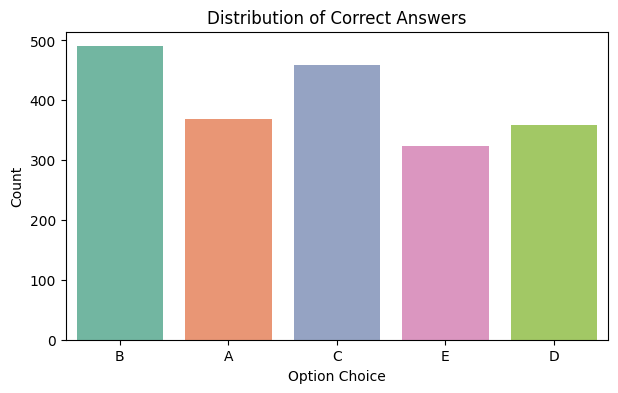

Answer Distribution (%):
answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64


In [10]:
# Are the correct answers evenly spread across A, B, C, D, E?
#Checks if the correct answers are evenly spread or if a specific choice is favored.

plt.figure(figsize=(7, 4))
sns.countplot(data=train, x='answer', palette='Set2')
plt.title('Distribution of Correct Answers')
plt.xlabel('Option Choice')
plt.ylabel('Count')
plt.show()

# Print percentages
print("Answer Distribution (%):")
print(train['answer'].value_counts(normalize=True) * 100)

**Option length bias**

Average word count:
Correct Options   : 28.66 words
Wrong Options (avg): 25.68 words


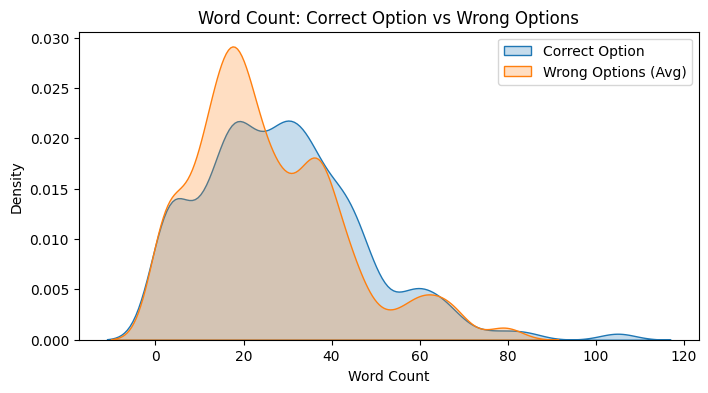

In [11]:
# Question: Are correct answers usually longer or more detailed than wrong options?
option_cols = ['A', 'B', 'C', 'D', 'E']

# Count words in prompt and each option
train['prompt_len'] = train['prompt'].apply(lambda x: len(str(x).split()))

for col in option_cols:
    train[f'len_{col}'] = train[col].apply(lambda x: len(str(x).split()))

# Compare correct option length vs average wrong option length
def calculate_lengths(row):
    correct_ans = row['answer']
    correct_len = row[f'len_{correct_ans}']
    
    wrong_cols = [c for c in option_cols if c != correct_ans]
    avg_wrong_len = np.mean([row[f'len_{c}'] for c in wrong_cols])
    
    return pd.Series([correct_len, avg_wrong_len])

train[['correct_len', 'avg_wrong_len']] = train.apply(calculate_lengths, axis=1)

print("Average word count:")
print(f"Correct Options   : {train['correct_len'].mean():.2f} words")
print(f"Wrong Options (avg): {train['avg_wrong_len'].mean():.2f} words")

# Plot length distributions
plt.figure(figsize=(8, 4))
sns.kdeplot(train['correct_len'], label='Correct Option', fill=True)
sns.kdeplot(train['avg_wrong_len'], label='Wrong Options (Avg)', fill=True)
plt.title('Word Count: Correct Option vs Wrong Options')
plt.xlabel('Word Count')
plt.legend()
plt.show()

**Trick questions (Negation Words)**


Questions with negation words (NOT/EXCEPT): 0 (0.0%)


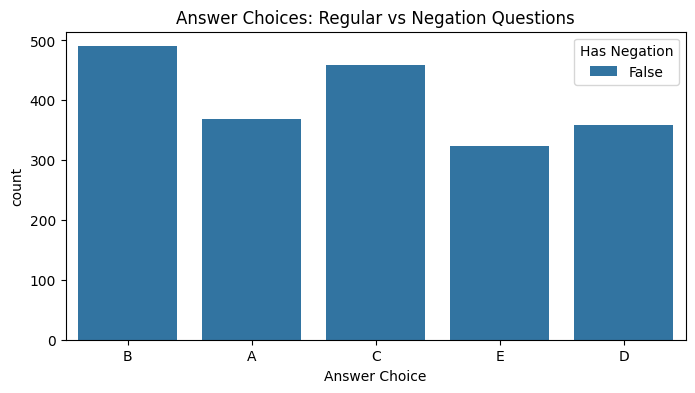

In [12]:
# Check for words like NOT, EXCEPT, INCORRECT in the prompt
negation_words = ['NOT', 'EXCEPT', 'INCORRECT', 'FALSE', 'LEAST']
pattern = r'\b(' + '|'.join(negation_words) + r')\b'

train['has_negation'] = train['prompt'].apply(
    lambda x: bool(re.search(pattern, str(x), re.IGNORECASE))
)

neg_count = train['has_negation'].sum()
print(f"\nQuestions with negation words (NOT/EXCEPT): {neg_count} ({neg_count / len(train) * 100:.1f}%)")

# Compare answer choices for regular vs negation questions
plt.figure(figsize=(8, 4))
sns.countplot(data=train, x='answer', hue='has_negation')
plt.title('Answer Choices: Regular vs Negation Questions')
plt.xlabel('Answer Choice')
plt.legend(title='Has Negation')
plt.show()

**Prompt and options overlap**

In [13]:
# Do correct options share more words with the question prompt
#Tests if simple keyword matching helps choose the right answer or 
#if distractors deliberately reuse words from the question to trick the model

def get_word_overlap(prompt, option):
    prompt_words = set(str(prompt).lower().split())
    option_words = set(str(option).lower().split())
    if not option_words:
        return 0
    # Proportion of option words present in the prompt
    return len(prompt_words.intersection(option_words)) / len(option_words)

# Calculate overlap for each option
for col in option_cols:
    train[f'overlap_{col}'] = train.apply(lambda r: get_word_overlap(r['prompt'], r[col]), axis=1)

# What if we simply guess the option with the highest word overlap?
train['highest_overlap_choice'] = (
    train[[f'overlap_{col}' for col in option_cols]]
    .idxmax(axis=1)
    .str.replace('overlap_', '')
)

simple_overlap_acc = (train['highest_overlap_choice'] == train['answer']).mean()
print(f"Accuracy of choosing option with highest word overlap: {simple_overlap_acc * 100:.2f}%")

Accuracy of choosing option with highest word overlap: 9.25%


**Train & Test comparision**

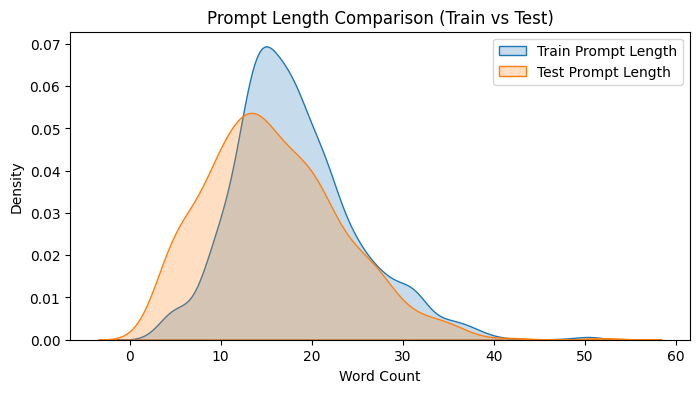

In [14]:
#Verifies that train and test prompt lengths follow a similar pattern so the model generalizes well

test['prompt_len'] = test['prompt'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8, 4))
sns.kdeplot(train['prompt_len'], label='Train Prompt Length', fill=True)
sns.kdeplot(test['prompt_len'], label='Test Prompt Length', fill=True)
plt.title('Prompt Length Comparison (Train vs Test)')
plt.xlabel('Word Count')
plt.legend()
plt.show()

**Tokenizer & Dataset Classes**

In [15]:
# SIMPLE VOCABULARY & TOKENIZER

class SimpleTokenizer:
    def __init__(self, vocab_size=25000):
        self.vocab_size = vocab_size
        self.word2idx = {'<pad>': 0, '<unk>': 1}
        self.idx2word = {0: '<pad>', 1: '<unk>'}
        
    def tokenize(self, text):
        return re.findall(r'\w+', str(text).lower())
        
    def build_vocab(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(self.tokenize(text))
            
        most_common = counter.most_common(self.vocab_size - 2)
        for idx, (word, _) in enumerate(most_common, start=2):
            self.word2idx[word] = idx
            self.idx2word[idx] = word
            
    def encode(self, text, max_len):
        tokens = self.tokenize(text)
        ids = [self.word2idx.get(tok, 1) for tok in tokens[:max_len]]
        if len(ids) < max_len:
            ids = ids + [0] * (max_len - len(ids))
        return ids


# MCQ DATASET CLASS

class MCQCNNDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, is_train=True):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train
        self.options = ['A', 'B', 'C', 'D', 'E']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt = str(row['prompt'])
        
        option_tokens = []
        for opt in self.options:
            combined_text = prompt + " " + str(row[opt])
            tokens = self.tokenizer.encode(combined_text, self.max_len)
            option_tokens.append(tokens)

        item = {
            'input_ids': torch.tensor(option_tokens, dtype=torch.long) # Shape: (5, max_len)
        }

        if self.is_train and 'answer' in row:
            item['labels'] = torch.tensor(LABEL2IDX[row['answer']], dtype=torch.long)

        return item

**Model Architecture**

In [16]:
class MCQTextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, filter_sizes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=k)
            for k in filter_sizes
        ])
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filter_sizes) * num_filters, 1)

    def forward(self, x):
        batch_size, num_options, seq_len = x.shape
        x = x.view(-1, seq_len)
        
        embeds = self.embedding(x)
        embeds = embeds.permute(0, 2, 1)
        
        pooled_outputs = []
        for conv in self.convs:
            c = F.relu(conv(embeds))
            p = F.max_pool1d(c, kernel_size=c.shape[2]).squeeze(2)
            pooled_outputs.append(p)
            
        cat = torch.cat(pooled_outputs, dim=1)
        cat = self.dropout(cat)
        
        logits = self.fc(cat)
        logits = logits.view(batch_size, num_options)
        return logits

**Data Preparation**

In [17]:
full_df = train

print("Building Vocabulary...")
tokenizer = SimpleTokenizer(vocab_size=CONFIG['vocab_size'])
all_texts = full_df['prompt'].tolist() + full_df['A'].tolist() + full_df['B'].tolist() + full_df['C'].tolist() + full_df['D'].tolist() + full_df['E'].tolist()
tokenizer.build_vocab(all_texts)

train_df, val_df = train_test_split(
    full_df,
    test_size=0.15,
    random_state=CONFIG['seed'],
    stratify=full_df['answer']
)

train_dataset = MCQCNNDataset(train_df, tokenizer, CONFIG['max_len'], is_train=True)
val_dataset = MCQCNNDataset(val_df, tokenizer, CONFIG['max_len'], is_train=True)


Building Vocabulary...


**Training function**

In [18]:
def run_experiment(run_config, run_name):
    """
    Trains one MCQTextCNN with the given hyperparameters, logs accuracy and
    F1 (macro) for train/val every epoch to its own WandB run, and saves the
    best checkpoint for this run.
    """
    set_seed(run_config['seed'])

    train_loader = DataLoader(train_dataset, batch_size=run_config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=run_config['batch_size'], shuffle=False)

    model = MCQTextCNN(
        vocab_size=len(tokenizer.word2idx),
        embed_dim=run_config['embed_dim'],
        num_filters=run_config['num_filters'],
        filter_sizes=run_config['filter_sizes'],
        dropout=run_config['dropout']
    ).to(run_config['device'])

    optimizer = AdamW(model.parameters(), lr=run_config['lr'], weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    wandb.init(
        project=run_config['project'],
        name=run_name,
        config=run_config,
        reinit=True,
        settings=wandb.Settings(save_code=False)
    )

    model_path = f"/kaggle/working/{run_name}.pth"
    best_val_acc = 0.0
    best_val_f1 = 0.0
    history = []

    print(f"\n=== Starting run: {run_name} ===")
    for epoch in range(run_config['epochs']):
        model.train()
        total_train_loss = 0
        train_preds, train_targets = [], []

        for batch in tqdm(train_loader, desc=f"[{run_name}] Epoch {epoch+1}/{run_config['epochs']} [Train]"):
            input_ids = batch['input_ids'].to(run_config['device'])
            labels = batch['labels'].to(run_config['device'])

            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_train_loss += loss.item()
            preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
            train_preds.extend(preds)
            train_targets.extend(labels.cpu().numpy())

        avg_train_loss = total_train_loss / len(train_loader)
        train_acc = accuracy_score(train_targets, train_preds)
        train_f1 = f1_score(train_targets, train_preds, average='macro')

        # Validation
        model.eval()
        total_val_loss = 0
        val_preds, val_targets = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"[{run_name}] Epoch {epoch+1}/{run_config['epochs']} [Val]"):
                input_ids = batch['input_ids'].to(run_config['device'])
                labels = batch['labels'].to(run_config['device'])

                logits = model(input_ids)
                loss = criterion(logits, labels)

                total_val_loss += loss.item()
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_targets.extend(labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average='macro')

        print(f"[{run_name}] Epoch {epoch+1}: "
              f"train_loss={avg_train_loss:.4f} train_acc={train_acc:.4f} train_f1={train_f1:.4f} | "
              f"val_loss={avg_val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}")

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": avg_val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1
        })

        history.append({
            "epoch": epoch + 1, "train_loss": avg_train_loss, "train_acc": train_acc,
            "train_f1": train_f1, "val_loss": avg_val_loss, "val_acc": val_acc, "val_f1": val_f1
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_f1 = val_f1
            torch.save(model.state_dict(), model_path)
            print(f"[{run_name}] Saved best checkpoint (val_acc={val_acc:.4f}, val_f1={val_f1:.4f}) -> {model_path}")

    if not os.path.exists(model_path):
        torch.save(model.state_dict(), model_path)

    wandb.summary["best_val_acc"] = best_val_acc
    wandb.summary["best_val_f1"] = best_val_f1
    wandb.finish()

    return {
        "run_name": run_name,
        "config": run_config,
        "model_path": model_path,
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1,
        "history": history
    }


**Run Experiments (>= 3 configs, tracked in WandB)**

In [19]:
base_config = dict(CONFIG)

experiment_configs = [
    {**base_config, "embed_dim": 128, "num_filters": 100, "filter_sizes": [3, 4, 5], "dropout": 0.3, "lr": 1e-3},
    {**base_config, "embed_dim": 200, "num_filters": 150, "filter_sizes": [2, 3, 4], "dropout": 0.4, "lr": 5e-4},
    {**base_config, "embed_dim": 100, "num_filters": 64,  "filter_sizes": [3, 4, 5], "dropout": 0.2, "lr": 2e-3},
]

run_results = []
for i, exp_cfg in enumerate(experiment_configs, start=1):
    run_name = f"{CONFIG['entity']}-run{i}"
    result = run_experiment(exp_cfg, run_name)
    run_results.append(result)

print(f"All {len(run_results)} experiment runs complete.")


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



=== Starting run: 22f1000828-t1-2026-indian-institute-of-technology-madras-run1 ===


[22f1000828-t1-2026-indian-institute-of-technology-madras-run1] Epoch 1/15 [Train]: 100%|██████████| 54/54 [00:02<00:00, 21.02it/s]
[22f1000828-t1-2026-indian-institute-of-technology-madras-run1] Epoch 1/15 [Val]: 100%|██████████| 10/10 [00:00<00:00, 88.84it/s]


[22f1000828-t1-2026-indian-institute-of-technology-madras-run1] Epoch 1: train_loss=1.2136 train_acc=0.5365 train_f1=0.5318 | val_loss=0.6523 val_acc=0.9733 val_f1=0.9714
[22f1000828-t1-2026-indian-institute-of-technology-madras-run1] Saved best checkpoint (val_acc=0.9733, val_f1=0.9714) -> /kaggle/working/22f1000828-t1-2026-indian-institute-of-technology-madras-run1.pth


[22f1000828-t1-2026-indian-institute-of-technology-madras-run1] Epoch 2/15 [Train]: 100%|██████████| 54/54 [00:00<00:00, 60.21it/s]
[22f1000828-t1-2026-indian-institute-of-technology-madras-run1] Epoch 2/15 [Val]: 100%|██████████| 10/10 [00:00<00:00, 90.72it/s]


...

[22f1000828-t1-2026-indian-institute-of-technology-madras-run3] Epoch 14: train_loss=0.0029 train_acc=0.9994 train_f1=0.9993 | val_loss=0.0001 val_acc=1.0000 val_f1=1.0000


[22f1000828-t1-2026-indian-institute-of-technology-madras-run3] Epoch 15/15 [Train]: 100%|██████████| 54/54 [00:10<00:00,  5.05it/s]
[22f1000828-t1-2026-indian-institute-of-technology-madras-run3] Epoch 15/15 [Val]: 100%|██████████| 10/10 [00:00<00:00, 108.50it/s]

[22f1000828-t1-2026-indian-institute-of-technology-madras-run3] Epoch 15: train_loss=0.0028 train_acc=0.9994 train_f1=0.9994 | val_loss=0.0001 val_acc=1.0000 val_f1=1.0000


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▆▇████████████
train_f1,▁▆▇████████████
train_loss,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁██████████████
val_f1,▁██████████████
val_loss,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,1
best_val_f1,1
epoch,15
train_acc,0.99941


All 3 experiment runs complete.


**Compare Runs (Accuracy & F1)**

Run comparison (also visible on your WandB project dashboard):
                                            run_name  embed_dim  num_filters  \
0  22f1000828-t1-2026-indian-institute-of-technol...        128          100   
1  22f1000828-t1-2026-indian-institute-of-technol...        200          150   
2  22f1000828-t1-2026-indian-institute-of-technol...        100           64   

   dropout      lr  best_val_acc  best_val_f1  
0      0.3  0.0010           1.0          1.0  
1      0.4  0.0005           1.0          1.0  
2      0.2  0.0020           1.0          1.0  


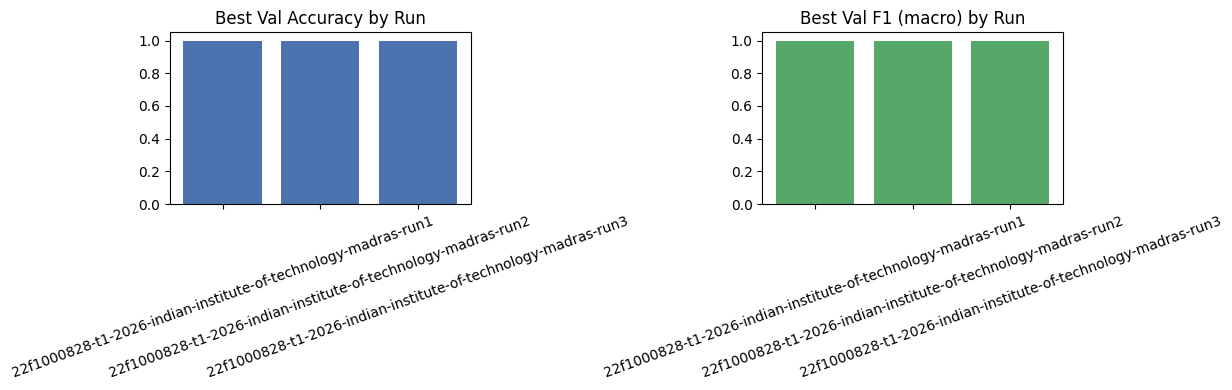

Best run: 22f1000828-t1-2026-indian-institute-of-technology-madras-run1 (val_acc=1.0000, val_f1=1.0000)
Using checkpoint: /kaggle/working/22f1000828-t1-2026-indian-institute-of-technology-madras-run1.pth


In [20]:
comparison_df = pd.DataFrame([
    {
        "run_name": r["run_name"],
        "embed_dim": r["config"]["embed_dim"],
        "num_filters": r["config"]["num_filters"],
        "dropout": r["config"]["dropout"],
        "lr": r["config"]["lr"],
        "best_val_acc": r["best_val_acc"],
        "best_val_f1": r["best_val_f1"],
    }
    for r in run_results
]).sort_values("best_val_acc", ascending=False).reset_index(drop=True)

print("Run comparison (also visible on your WandB project dashboard):")
print(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(comparison_df["run_name"], comparison_df["best_val_acc"], color="#4C72B0")
axes[0].set_title("Best Val Accuracy by Run")
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(comparison_df["run_name"], comparison_df["best_val_f1"], color="#55A868")
axes[1].set_title("Best Val F1 (macro) by Run")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

best_run = max(run_results, key=lambda r: r["best_val_acc"])
BEST_MODEL_PATH = best_run["model_path"]
BEST_RUN_CONFIG = best_run["config"]
print(f"Best run: {best_run['run_name']} (val_acc={best_run['best_val_acc']:.4f}, val_f1={best_run['best_val_f1']:.4f})")
print(f"Using checkpoint: {BEST_MODEL_PATH}")


**Inference & Submission**

In [21]:
# Rebuild the best-performing run's model and load its saved weights
model = MCQTextCNN(
    vocab_size=len(tokenizer.word2idx),
    embed_dim=BEST_RUN_CONFIG['embed_dim'],
    num_filters=BEST_RUN_CONFIG['num_filters'],
    filter_sizes=BEST_RUN_CONFIG['filter_sizes'],
    dropout=BEST_RUN_CONFIG['dropout']
)
state_dict = torch.load(BEST_MODEL_PATH, map_location=CONFIG['device'])
model.load_state_dict(state_dict)
model.to(CONFIG['device'])
model.eval()

# Build the test dataloader
test_dataset = MCQCNNDataset(test, tokenizer, CONFIG['max_len'], is_train=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

# Run inference
all_probs = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Generating Test Predictions"):
        input_ids = batch['input_ids'].to(CONFIG['device'])
        logits = model(input_ids)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)

all_probs = np.vstack(all_probs)

# MAP@3 needs the top 3 ranked labels per question, not just the top 1
top3_idx = np.argsort(-all_probs, axis=1)[:, :3]
predictions = [" ".join(IDX2LABEL[i] for i in row) for row in top3_idx]

submission = pd.DataFrame({
    'id': test['id'] if 'id' in test.columns else np.arange(len(test)),
    'Prediction': predictions
})

submission.to_csv("submission.csv", index=False)
print("submission.csv generated successfully")
print(submission.head())


Generating Test Predictions: 100%|██████████| 16/16 [00:00<00:00, 106.27it/s]

submission.csv generated successfully
   id Prediction
0   1      A E C
1   2      B A E
2   3      B E D
3   4      E C D
4   5      C A D
